### K-Means Algorithm

#### K meansın rakamlara uygulanması

In [8]:
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [9]:
import seaborn as sns; sns.set()
digits = load_digits()

In [11]:
est = KMeans(n_clusters=10)
clusters = est.fit_predict(digits.data)
est.cluster_centers_.shape

(10, 64)

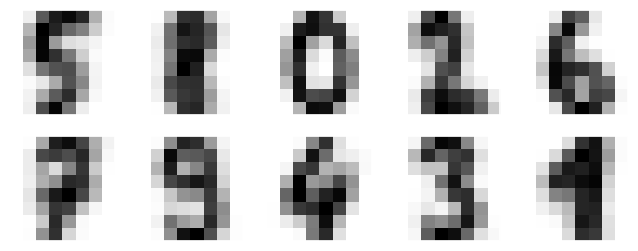

In [18]:
fig = plt.figure(figsize=(8, 3))
for i in range(10):
    ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])
    ax.imshow(est.cluster_centers_[i].reshape((8, 8)), cmap=plt.cm.binary)

In [13]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [14]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7913188647746243

[[177   0   0   0   1   0   0   0   0   0]
 [  0  55  24   1   0   1   2   0  99   0]
 [  1   2 148  13   0   0   0   3   8   2]
 [  0   0   0 154   0   2   0   7   7  13]
 [  0   5   0   0 164   0   0   8   4   0]
 [  0   0   0   1   1 137   1   0   0  42]
 [  1   1   0   0   0   0 177   0   2   0]
 [  0   2   0   0   0   5   0 170   2   0]
 [  0   6   3   2   0   8   2   2 101  50]
 [  0  20   0   6   0   7   0   7   1 139]]


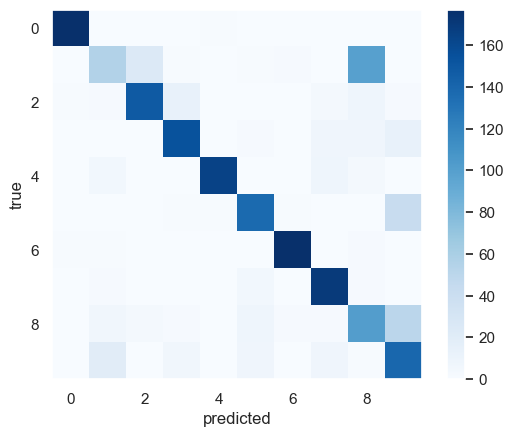

In [20]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(digits.target,labels))
plt.imshow(confusion_matrix(digits.target, labels),
          cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.grid(False)
plt.ylabel('true')
plt.xlabel('predicted');